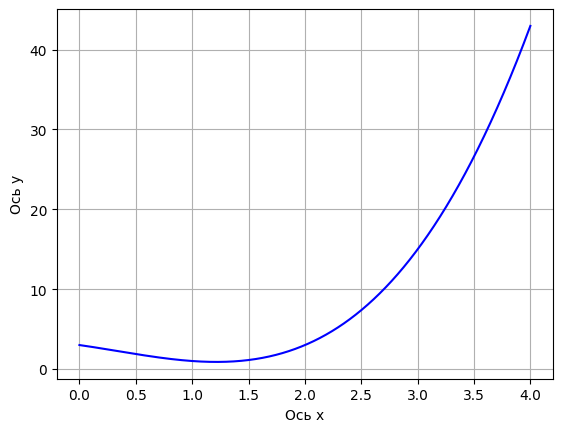

In [98]:
import matplotlib.pyplot as plt
import numpy as np
def f(x):
    return x**3 - x**2 - 2*x + 3

x = np.arange(0, 4, 0.001)
plt.xlabel('Ось х')
plt.ylabel('Ось y')
plt.grid(True)

plt.plot(x, f(x), color='blue')
plt.show()


In [99]:
l = 0.5
eps = 0.05
n = 6
a = np.zeros(n+1)
a[0] = 1
b = np.zeros(n+1)
b[0] = 4
def fib(n):
        fib_0, fib_1 = 1, 1
        for _ in range(2, n + 1):
            fib_0, fib_1 = fib_1, fib_1 + fib_0
        return fib_1
lamb = np.zeros(n+1)
lamb[0] = a[0] + fib(n-2)*(b[0]-a[0])/fib(n)
myo = np.zeros(n+1)
myo[0] = a[0] + fib(n-1)*(b[0]-a[0])/fib(n)
for i in range(n):
    if f(lamb[i]) > f(myo[i]):
        a[i+1] = lamb[i]
        b[i+1] = b[i]
        lamb[i+1] = myo[i]
        myo[i+1] = a[i+1] + (fib(n-i-1) / fib(n-i)) * (b[i+1] - a[i+1])
    else:
        a[i+1] = a[i]
        b[i+1] = myo[i]
        myo[i+1] = lamb[i]
        lamb[i+1] = a[i+1] + (fib(n-i-2) / fib(n-i)) * (b[i+1] - a[i+1])
    if i == n-2:
            lamb[n] = lamb[n-1]
            myo[n] = lamb[n] + eps
            if f(lamb[n]) == f(myo[n]):
                a[n] = lamb[n]
            elif f(lamb[n]) < f(myo[n]):
                a[n] = a[n-1]
                b[n] = myo[n]
                   
                 
x_min = (a[n] + b[n])/2
print(x_min)
print(f(x_min))


1.2163461538461537
0.8873913868698793


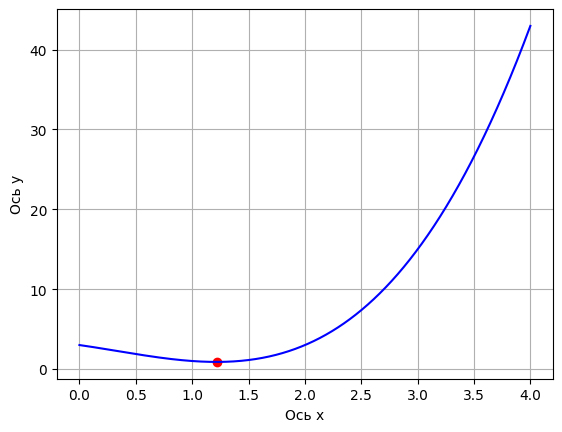

In [100]:
x = np.arange(0, 4, 0.001)
plt.xlabel('Ось х')
plt.ylabel('Ось y')
plt.grid(True)

plt.scatter(x_min, f(x_min), color = 'red')
plt.plot(x, f(x), color='blue')


In [101]:
def df(x):
    return 3*x**2 - 2*x - 2
a = 1
b = 4
L = max([np.abs(df(i)) for i in np.arange(a, b, 0.1)])
eps = 0.05
x_0 = (f(a)-f(b)+L*(a+b))/(2*L)
phi_min = 0.5*(f(a)+f(b)+L*(a-b))
delta = (f(x_0)-phi_min)/(2*L)
while(2*L*delta > eps):
    x_l = x_0 - delta
    x_r = x_0 + delta
    phi_min = 0.5*(f(x_0)+phi_min)
    if (f(x_l) < f(x_r)):
        x_0 = x_l
    else:
        x_0 = x_r
    new_delta = (f(x_0)-phi_min)/(2*L)
    delta = new_delta
x_min = x_0
print(x_min)
print(f(x_min))


1.2150183405030568
0.887388351588549


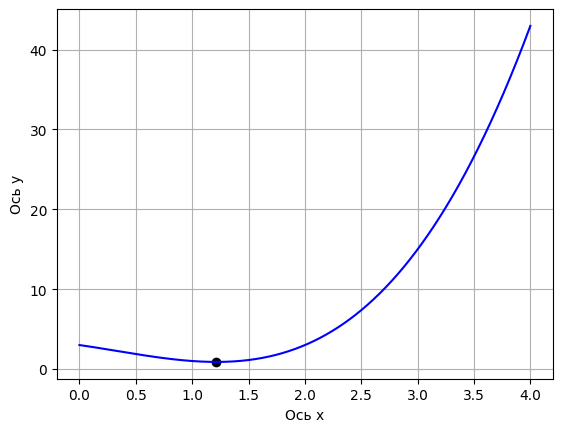

In [102]:
x = np.arange(0, 4, 0.001)
plt.xlabel('Ось х')
plt.ylabel('Ось y')
plt.grid(True)

plt.scatter(x_min, f(x_min), color = 'black')
plt.plot(x, f(x), color='blue')

plt.show()


In [103]:
def ddf(x):
    return 6*x - 2
eps = 0.05
a = 1
b = 4
x = (1+1.5)/2
ddf0 = ddf(x)
while (np.abs(df(x)) > eps):
    x = x - df(x)/ddf0
x_min = x
print(x_min)
print(f(x_min))



1.2159090909090908
0.8873893571562732


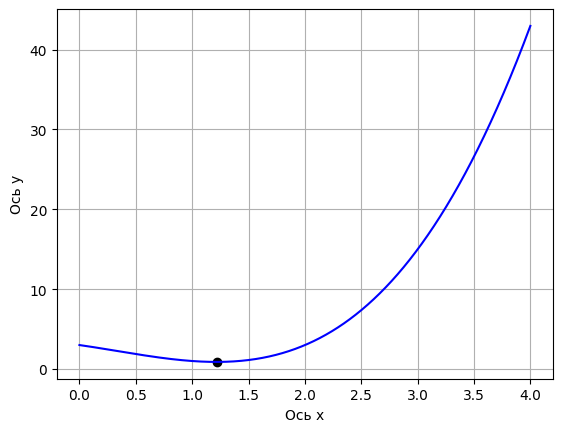

In [104]:
x = np.arange(0, 4, 0.001)
plt.xlabel('Ось х')
plt.ylabel('Ось y')
plt.grid(True)

plt.scatter(x_min, f(x_min), color = 'black')
plt.plot(x, f(x), color='blue')

plt.show()


In [105]:
eps = 0.05
a = 1
b = 4
x = (1+1.5)/2
while (np.abs(df(x)) > eps):
    x = x - df(x)/ddf(x)
x_min = x
print(x_min)
print(f(x_min))


1.2159090909090908
0.8873893571562732


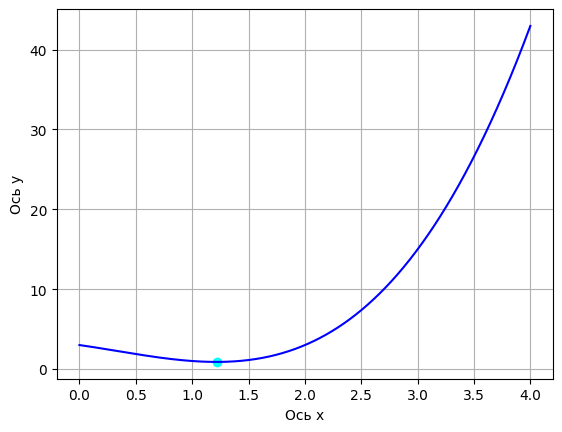

In [106]:
x = np.arange(0, 4, 0.001)
plt.xlabel('Ось х')
plt.ylabel('Ось y')
plt.grid(True)

plt.scatter(x_min, f(x_min), color = 'cyan')
plt.plot(x, f(x), color='blue')

plt.show()


In [107]:
import scipy as sp
sc_min = sp.optimize.minimize(f, 1.2)
sc_min


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.8873882090828484
        x: [ 1.215e+00]
      nit: 2
      jac: [ 7.510e-06]
 hess_inv: [[ 1.906e-01]]
     nfev: 8
     njev: 4

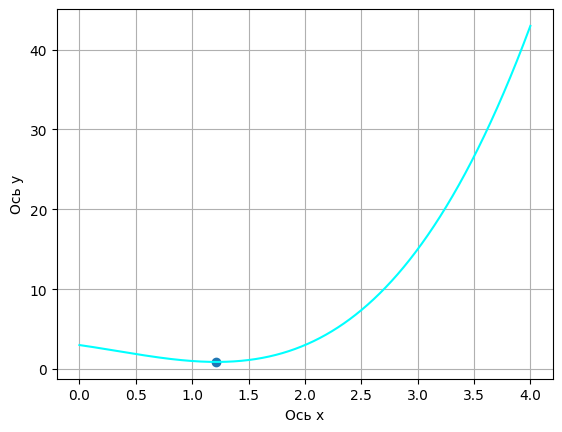

In [108]:
x = np.arange(0, 4, 0.001)
plt.xlabel('Ось х')
plt.ylabel('Ось y')
plt.grid(True)

plt.plot(x, f(x), color='cyan')
plt.scatter(sc_min.x, sc_min.fun)

plt.show()


In [111]:
import pandas as pd
data = {'Method': ['Analytical Fibonacci', 'NP Fibonacci', 'Analytical polylines', 'NP polylines', 'Analytical simplified Newton method', 'NP simplified Newton method', 'Analytical Newton method', 'NP Newton method'],
        'x_min': [1.2125, 1.2163461538461537, 1.21440048, 1.2150183405030568, 1.223, 1.2159090909090908, 1.217, 1.2159090909090908], 
        'y_min': [0.8874, 0.8873913868698793, 0.8873901, 0.887388351588549, 0.887548, 0.8873893571562732, 0.887396, 0.8873893571562732],
        'Error': [abs(sc_min.fun - 0.8874), abs(sc_min.fun - 0.8873913868698793), abs(sc_min.fun - 0.8873901), abs(sc_min.fun - 0.887388351588549), abs(sc_min.fun - 0.887548), abs(sc_min.fun - 0.8875203429504093), abs(sc_min.fun - 0.887396), abs(sc_min.fun - 0.8873963775878457)]}

df = pd.DataFrame(data)
df
# import pandas as pd
# data = {'Method': ['Fibonacci', 'polylines', 'simplified Newton method',
#                     'Newton method'],
#         'Error': [abs(0.8873913868698793 - 0.8874), abs(0.887388351588549 - 0.8873901), abs(0.8875203429504093- 0.887548), abs(0.8873963775878457 - 0.887396)]}

# df = pd.DataFrame(data)
# df

,Method,x_min,y_min,Error
0,Analytical Fibonacci,1.212500,0.887400,1.179092e-05
1,NP Fibonacci,1.216346,0.887391,3.177787e-06
2,Analytical polylines,1.214400,0.887390,1.890917e-06
3,NP polylines,1.215018,0.887388,1.425057e-07
4,Analytical simplified Newton method,1.223000,0.887548,1.597909e-04
5,NP simplified Newton method,1.215909,0.887389,1.321339e-04
6,Analytical Newton method,1.217000,0.887396,7.790917e-06
7,NP Newton method,1.215909,0.887389,8.168505e-06


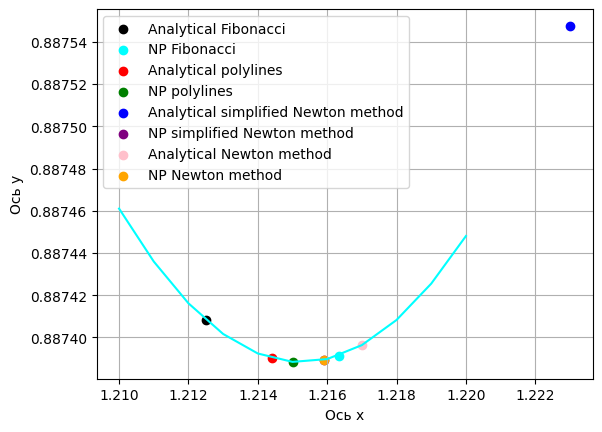

In [114]:
x = np.arange(1.21, 1.22, 0.001)
plt.xlabel('Ось х')
plt.ylabel('Ось y')
plt.grid(True)

plt.plot(x, f(x), color='cyan')
minimums = data['x_min']
colors = ['black', 'cyan', 'red','green', 'blue', 'purple', 'pink', 'orange']
labels = data['Method']

for i in range(8):
    plt.scatter(minimums[i], f(minimums[i]), color = colors[i], label = labels[i])
#plt.scatter(sc_min.x, sc_min.fun, marker ='s', color = 'magenta', label = 'Scipy')
plt.legend()
plt.show()